In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Task 1: Dataset Understanding

Rows and Columns

In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 541909, Columns: 8


Data Types

In [3]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Numerical Features

In [4]:
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical features:", numerical)

Numerical features: ['Quantity', 'UnitPrice', 'CustomerID']


Categorical Features

In [5]:
categorical = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", categorical)

Categorical features: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


Possible Unique Identifiers (Primary Keys)

In [6]:
dupe_combo = df.duplicated(subset=['InvoiceNo', 'StockCode']).sum()
print(f"Duplicate InvoiceNo+StockCode combinations: {dupe_combo}")

Duplicate InvoiceNo+StockCode combinations: 10684


Missing Values Overview

In [7]:
df.isnull().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

Dataset DescriptionThis dataset contains transactional records from a UK-based online retailer. Each row represents a singleproduct line item within a customer invoice, capturing the invoice number, product/stock code, productdescription, quantity purchased, transaction date and time, unit price, customer ID, and country of purchase.There is no single-column primary key; the natural grain of the data is one row per product per invoice.

## Task 2: Data Cleaning

## 1. Missing Values

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
CustomerID,135080,24.926694
Description,1454,0.268311


## 2. Duplicate Records

In [9]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Duplicates removed: {before - after}")

Rows before: 541909
Rows after: 536641
Duplicates removed: 5268


## 3. Standardization

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['Country'] = df['Country'].str.strip().str.title()
df['Description'] = df['Description'].str.strip().str.upper()
df.columns = df.columns.str.strip().str.lower()
df = df.dropna(subset=['customerid'])
df['customerid'] = df['customerid'].astype(int)
df.dtypes

invoiceno              object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
unitprice             float64
customerid              int64
country                object
dtype: object

## 4. Data Validation

In [18]:
# invalid_price 
invalid_price = df[df['unitprice'] <= 0]
print(f"Rows with zero or negative price: {len(invalid_price)}")

Rows with zero or negative price: 40


In [19]:
# Inconsistent records 
returns = df[df['quantity'] < 0]
print(f"Return/cancellation rows (negative quantity): {len(returns)}")

Return/cancellation rows (negative quantity): 8872


In [22]:
# Outliers 
price_outliers = df[df['unitprice'] > df['unitprice'].quantile(0.99)]
qty_outliers = df[df['quantity'] > df['quantity'].quantile(0.99)]
print(f"Top 1% price outliers: {len(price_outliers)}")
print(f"Top 1% quantity outliers: {len(qty_outliers)}")

Top 1% price outliers: 3857
Top 1% quantity outliers: 3894


## 5. Cleaning Summary

In [25]:
before_dropna = len(df)
df = df.dropna(subset=['customerid'])
after_dropna = len(df)
print(f"Rows dropped due to missing CustomerID: {before_dropna - after_dropna}")

Rows dropped due to missing CustomerID: 0


In [26]:
summary = pd.DataFrame({
    'Issue Found': [
        'Missing Description',        'Missing CustomerID',        'Duplicate rows',
        'Inconsistent date format',        'Inconsistent text casing',
        'Negative quantities (returns)',        'Zero/negative prices',        'Price/quantity outliers'
    ],
    'Action Taken': [
        "Filled with 'Unknown'",        f'Rows dropped ({before_dropna - after_dropna} rows) — no valid substitute for an ID',
        f'Removed ({before - after} rows)',        'Converted to datetime via pd.to_datetime',
        'Standardized casing (title/upper)',        'Flagged — represents legitimate returns, not errors',
        'Flagged for review',        'Flagged for review (top 1% by value)'    
    ]
})
summary

,Issue Found,Action Taken
0,Missing Description,Filled with 'Unknown'
1,Missing CustomerID,Rows dropped (0 rows) — no valid substitute fo...
2,Duplicate rows,Removed (5268 rows)
3,Inconsistent date format,Converted to datetime via pd.to_datetime
4,Inconsistent text casing,Standardized casing (title/upper)
5,Negative quantities (returns),"Flagged — represents legitimate returns, not e..."
6,Zero/negative prices,Flagged for review
7,Price/quantity outliers,Flagged for review (top 1% by value)


## Task 3: Exploratory Data Analysis (EDA)

# Summary Statistics for Numerical Columns

In [30]:
df[['quantity', 'unitprice']].agg(['mean', 'median', 'min', 'max', 'std']).T

,mean,median,min,max,std
quantity,12.183273,5.00,-80995.0,80995.0,250.283037
unitprice,3.474064,1.95,0.0,38970.0,69.764035


## Exploratory Analyses

1. Top-selling products (by quantity)

In [31]:
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53119
JUMBO BAG RED RETROSPOT               44963
ASSORTED COLOUR BIRD ORNAMENT         35215
WHITE HANGING HEART T-LIGHT HOLDER    34128
PACK OF 72 RETROSPOT CAKE CASES       33386
POPCORN HOLDER                        30492
RABBIT NIGHT LIGHT                    27045
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25305
PACK OF 60 PINK PAISLEY CAKE CASES    24129
Name: quantity, dtype: int64


2. Highest revenue-generating countries

In [33]:
df['revenue'] = df['quantity'] * df['unitprice']
top_countries_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_countries_revenue)

country
United Kingdom    6747156.154
Netherlands        284661.540
Eire               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: revenue, dtype: float64


3. Monthly sales trends

In [34]:
df['month'] = df['invoicedate'].dt.to_period('M')
monthly_sales = df.groupby('month')['revenue'].sum()
print(monthly_sales)

month
2010-12     552372.860
2011-01     473731.900
2011-02     435534.070
2011-03     578576.210
2011-04     425222.671
2011-05     647011.670
2011-06     606862.520
2011-07     573112.321
2011-08     615078.090
2011-09     929356.232
2011-10     973306.380
2011-11    1126815.070
2011-12     341539.430
Freq: M, Name: revenue, dtype: float64


4. Most purchased products (by frequency)

In [35]:
most_frequent = df['description'].value_counts().head(10)
print(most_frequent)

description
WHITE HANGING HEART T-LIGHT HOLDER    2058
REGENCY CAKESTAND 3 TIER              1894
JUMBO BAG RED RETROSPOT               1659
PARTY BUNTING                         1409
ASSORTED COLOUR BIRD ORNAMENT         1405
LUNCH BAG RED RETROSPOT               1345
SET OF 3 CAKE TINS PANTRY DESIGN      1224
POSTAGE                               1196
LUNCH BAG  BLACK SKULL.               1099
PACK OF 72 RETROSPOT CAKE CASES       1062
Name: count, dtype: int64


5. Customer purchasing behavior — top spenders

In [36]:
top_customers = df.groupby('customerid')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

customerid
14646    279489.02
18102    256438.49
17450    187322.17
14911    132458.73
12415    123725.45
14156    113214.59
17511     88125.38
16684     65892.08
13694     62690.54
15311     59284.19
Name: revenue, dtype: float64


6. Average order value by country (bonus)

In [37]:
avg_order_value = df.groupby(['country', 'invoiceno'])['revenue'].sum().groupby('country').mean().sort_values(ascending=False).head(10)
print(avg_order_value)

country
Netherlands    2818.431089
Australia      1985.648841
Lebanon        1693.880000
Japan          1262.165000
Israel         1164.733333
Brazil         1143.600000
Rsa            1002.310000
Singapore       912.039000
Denmark         893.720952
Norway          879.086500
Name: revenue, dtype: float64


7. Return rate overview (bonus)

In [39]:
total_rows = len(df)
return_rows = len(df[df['quantity'] < 0])
print(f"Return rate: {return_rows / total_rows * 100:.2f}%")

Return rate: 2.21%


## Task 4: Data Visualization

1. Bar Chart — Top 10 Best-Selling Products by Quantity

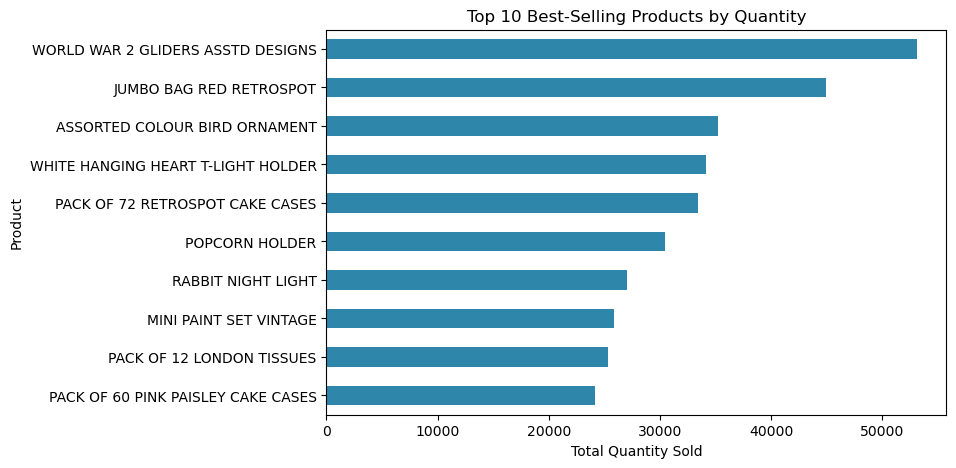

In [40]:
plt.figure(figsize=(8,5))
top_products.plot(kind='barh', color='#2E86AB')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.show()

2. Line Chart — Monthly Revenue Trend

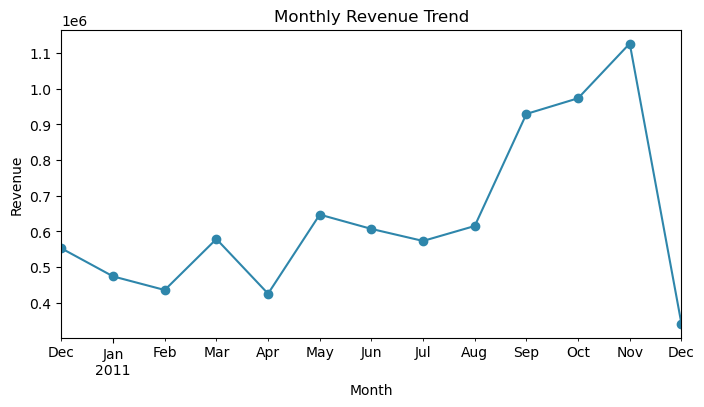

In [41]:
plt.figure(figsize=(8,4))
monthly_sales.plot(kind='line', marker='o', color='#2E86AB')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

3. Pie Chart — Revenue Share by Top 5 Countries

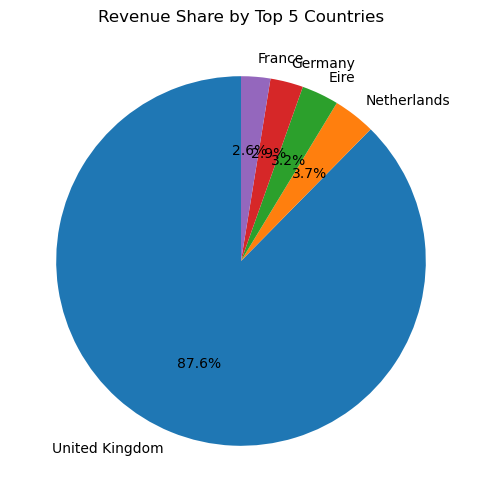

In [42]:
plt.figure(figsize=(6,6))
top5 = top_countries_revenue.head(5)
plt.pie(top5, labels=top5.index, autopct='%1.1f%%', startangle=90)
plt.title('Revenue Share by Top 5 Countries')
plt.show()

4. Histogram — Distribution of Quantity per Line Item

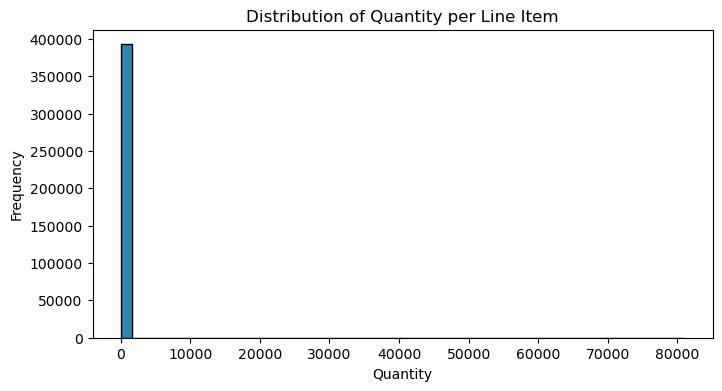

In [43]:
plt.figure(figsize=(8,4))
plt.hist(df[df['quantity'] > 0]['quantity'], bins=50, color='#2E86AB', edgecolor='black')
plt.title('Distribution of Quantity per Line Item')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

5. Box Plot — Unit Price Distribution

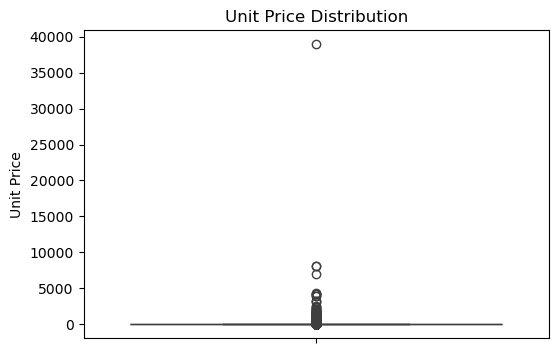

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df[df['unitprice'] > 0]['unitprice'])
plt.title('Unit Price Distribution')
plt.ylabel('Unit Price')
plt.show()

## 
Task 5: Insights
1. A small number of products drive most sales volume — the bar chart shows top sellers far outpacing the rest, suggesting inventory and marketing focus could concentrate on these items.
2. Revenue is highly seasonal — the line chart shows clear monthly peaks, likely tied to holiday shopping patterns, useful for staffing and stock planning ahead of high-demand periods.
3. The UK dominates revenue — as expected for a UK-based retailer, but the remaining international share (shown in the pie chart) may represent an underexplored growth opportunity.
4. Order sizes are typically small — the histogram shows most purchases are low-quantity, with occasional bulk buyers who may represent wholesale customers worth identifying and marketing to separately.
5. A small set of customers contribute disproportionate revenue — the top-spender analysis suggests a loyalty or VIP-treatment opportunity for high-value repeat customers.
Limitation: This dataset includes returns/cancellations (negative quantities) which should be interpreted carefully depending on whether the analysis goal is gross revenue, net revenue, or return-rate tracking.